# RQ3: alignment with human partitions (the CLEAR thesis exhibits)

CritClust here is CritClust_A under the **RQ1-aligned judge protocol** (fresh
1,000-document reference per seed; Flash judge wherever the LLM-source is matched,
glm-5 kept for unmatched; full record in `results/ALIGNED_PROTOCOL.md`). The vs-SOTA
comparisons and the ingredient factorial answer RQ4 and live in
`rq4_clean_results.ipynb`. Exhibits:

1. **Headline alignment**: per-benchmark NMI and ACC against the human labels
   (5-seed mean ± std, best-stack configuration: gemini-embedding-001 + glm-5).
2. **The k-means uplift**: the same numbers minus a same-embedder k-means control:
   what the LLM machinery (criterion codebook, judge selection, repair) adds while
   the geometry is held fixed.

In [1]:
# Shared setup for the RQ3 exhibits (paths, display names, plot style, save helper).
from pathlib import Path

import numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = Path.cwd().parents[1]              # repo root (this notebook lives in analysis/rq3/)
RESULTS = REPO / 'results' / 'clear'
FIGS = REPO / 'figures'

DISPL = {'banking77': 'Banking77', 'clinc150': 'CLINC(I)', 'clinc150_domain': 'CLINC(D)',
         'mtop_intent': 'MTOP(I)', 'mtop_domain': 'MTOP(D)', 'massive_intent': 'MASSIVE(I)',
         'massive_domain': 'MASSIVE(D)', 'tweet89': 'Tweet89', 'stackoverflow20': 'StackOverflow',
         'mcid': 'M-CID', 'snips': 'SNIPS', 'dbpedia': 'DBPedia', 'reddit_s2s': 'Reddit-S2S',
         'arxiv_fine': 'ArXiv-S2S', 'stackexchange_cl': 'StackEx-S2S', 'fewrel': 'FewRel',
         'fewnerd': 'FewNerd', 'fewevent': 'FewEvent', 'bbcnews': 'BBC News'}
_RCA = {'font.family': 'serif', 'mathtext.fontset': 'stix',
        'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif'],
        'axes.linewidth': 0.8, 'font.size': 9}
BLUE = '#0057ba'

def save(fig, stem):
    fig.savefig(FIGS / f'{stem}.pdf', bbox_inches='tight')
    print(f'saved figures/{stem}.pdf')


NC, AC = '#2066a8', '#80ae9a'   # NMI / ACC colours used throughout
SETTINGS = ['unmatched', 'matched', 'embmatched', 'llmmatched']
SEL = ['random', 'default', 'silhouette', 'judge', 'oracle']
NAMES = ['Random\n(expected)', 'Default\n(k-means)', 'Silhouette\nargmax',
         'Codebook\njudge', 'Oracle']
COLS = ['#7f7f7f', '#ff7f0e', '#d62728', '#1f77b4', '#2ca02c']

SC = pd.read_csv(RESULTS / 'critclust_C_unmatched_aligned_summary.csv')
SC['disp'] = SC.bench.map(DISPL)
SC = SC.sort_values('nmi_mean', ascending=False).reset_index(drop=True)


saved figures/rq3c_C_ex1f_grouped.pdf


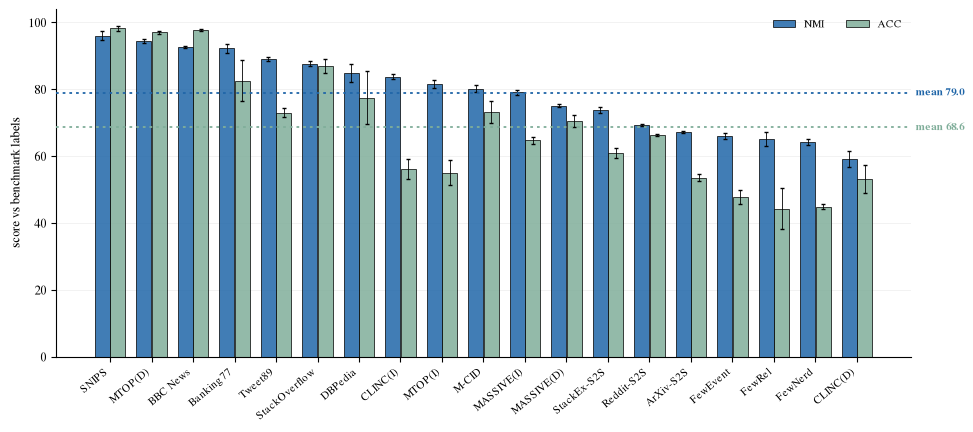

In [2]:
# C EXHIBIT 1f: grouped bars: NMI and ACC side by side per benchmark.
with plt.rc_context(_RCA):
    fig, ax = plt.subplots(figsize=(9.8, 4.4))
    x = np.arange(len(SC))
    W = 0.36
    ax.bar(x - W / 2 - 0.01, SC.nmi_mean, W, color=NC, alpha=0.85,
           edgecolor='black', lw=.6, zorder=2, label='NMI')
    ax.bar(x + W / 2 + 0.01, SC.acc_mean, W, color=AC, alpha=0.85,
           edgecolor='black', lw=.6, zorder=2, label='ACC')
    ax.errorbar(x - W / 2 - 0.01, SC.nmi_mean, yerr=SC.nmi_std, fmt='none',
                ecolor='black', elinewidth=.6, capsize=1.5, zorder=3)
    ax.errorbar(x + W / 2 + 0.01, SC.acc_mean, yerr=SC.acc_std, fmt='none',
                ecolor='black', elinewidth=.6, capsize=1.5, zorder=3)
    for m, c in ((SC.nmi_mean.mean(), NC), (SC.acc_mean.mean(), AC)):
        ax.axhline(m, color=c, lw=1.3, linestyle=(0, (1.5, 2.2)), zorder=4)
        ax.annotate(f'mean {m:.1f}', xy=(1.005, m),
                    xycoords=('axes fraction', 'data'), va='center', ha='left',
                    fontsize=7.8, fontweight='bold', color=c,
                    annotation_clip=False)
    ax.set_xticks(x)
    ax.set_xticklabels(SC.disp, rotation=40, ha='right', fontsize=8)
    ax.set_ylim(0, 104)
    ax.set_ylabel('score vs benchmark labels', fontsize=9)
    ax.legend(fontsize=8, frameon=False, loc='upper right', ncol=2)
    ax.grid(axis='y', alpha=0.18, lw=0.6)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    plt.tight_layout()
    save(fig, 'rq3c_C_ex1f_grouped')
    plt.show()

saved figures/rq3c_C_ex2b_uplift_styled.pdf


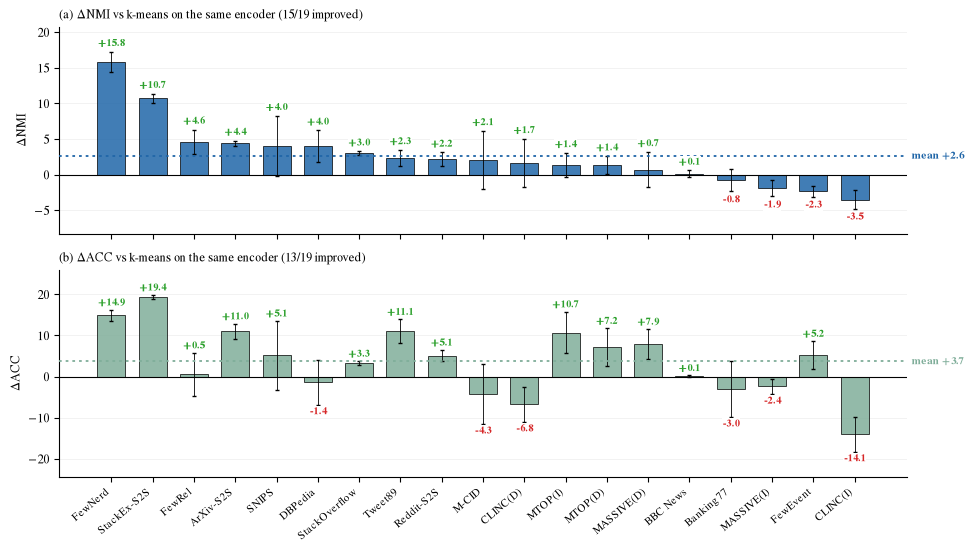

In [3]:
# C EXHIBIT 2b: uplift over seed-paired same-embedder k-means, styled like ex1f:
# two stacked panels (dNMI green, dACC purple), soft fills, dotted mean lines.
BR = pd.read_csv(RESULTS / 'baseline_unmatched_runs.csv')
CR = pd.read_csv(RESULTS / 'critclust_C_unmatched_aligned_runs.csv')
M = CR.merge(BR, on=['bench', 'seed'], suffixes=('', '_km'))
G = M.assign(dn=M.nmi - M.nmi_km, da=M.acc - M.acc_km).groupby('bench') \
     .agg(dn=('dn', 'mean'), dn_sd=('dn', 'std'),
          da=('da', 'mean'), da_sd=('da', 'std')).reset_index()
G['disp'] = G.bench.map(DISPL)
G = G.sort_values('dn', ascending=False).reset_index(drop=True)

with plt.rc_context(_RCA):
    fig, axs = plt.subplots(2, 1, figsize=(9.8, 5.6), sharex=True)
    x = np.arange(len(G))
    for ax, dcol, scol, col, lab, li in ((axs[0], 'dn', 'dn_sd', NC, 'NMI', 'a'),
                                         (axs[1], 'da', 'da_sd', AC, 'ACC', 'b')):
        wins = int((G[dcol] > 0).sum())
        ax.bar(x, G[dcol], 0.68, color=col, alpha=0.85, edgecolor='black',
               lw=.6, zorder=2)
        ax.errorbar(x, G[dcol], yerr=G[scol], fmt='none', ecolor='black',
                    elinewidth=.6, capsize=1.5, zorder=3)
        for xi, v, s_ in zip(x, G[dcol], G[scol]):
            up = v >= 0
            ax.text(xi, v + (s_ + 0.45 if up else -s_ - 0.45), f'{v:+.1f}',
                    ha='center', va='bottom' if up else 'top', fontsize=7.4,
                    fontweight='bold', color=('#2ca02c' if up else '#d62728'), zorder=5,
                    bbox=dict(facecolor='white', edgecolor='none', pad=0.5,
                              alpha=1.0))
        ax.margins(y=0.16)
        ax.axhline(0, color='black', lw=.8)
        m = G[dcol].mean()
        ax.axhline(m, color=col, lw=1.3, linestyle=(0, (1.5, 2.2)), zorder=4)
        ax.annotate(f'mean {m:+.1f}', xy=(1.005, m),
                    xycoords=('axes fraction', 'data'), va='center', ha='left',
                    fontsize=7.8, fontweight='bold', color=col,
                    annotation_clip=False)
        ax.set_title(f'({li}) Δ{lab} vs k-means on the same encoder '
                     f'({wins}/19 improved)', fontsize=9, loc='left')
        ax.set_ylabel(f'Δ{lab}')
        ax.grid(axis='y', alpha=0.18, lw=0.6)
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(G.disp, rotation=40, ha='right', fontsize=8)
    plt.tight_layout()
    save(fig, 'rq3c_C_ex2b_uplift_styled')
    plt.show()

In [4]:
# C EXHIBIT 3: which candidate the judge picked (all four aligned settings).
allw = []
for st in SETTINGS:
    f = RESULTS / f'critclust_C_{st}_aligned_runs.csv'
    if not f.exists():
        print(f'{st}: not available yet'); continue
    d = pd.read_csv(f)
    tot = d.winner.value_counts()
    allw.append(tot.rename(st))
    print(f'{st}: ' + ', '.join(f'{k2} x{v}' for k2, v in tot.items()))
if allw:
    WC = pd.concat(allw, axis=1).fillna(0).astype(int)
    WC['total'] = WC.sum(axis=1)
    WC = WC.sort_values('total', ascending=False)
    print('\n=== winner totals across settings')
    print(WC.to_string())
    WC.to_csv(RESULTS / 'aligned_winner_counts_C.csv')

unmatched: exemplar_raw x37, exemplar_concat x30, kmeans_raw x15, agglo_raw x4, gmm_concat x4, km_concat x3, gmm_raw x1, km_rewrite x1
matched: exemplar_concat x26, exemplar_raw x20, kmeans_raw x19, gmm_concat x10, agglo_raw x9, km_concat x8, gmm_raw x3
embmatched: exemplar_concat x46, exemplar_raw x13, km_concat x13, gmm_concat x6, agglo_raw x6, kmeans_raw x5, km_rewrite x3, gmm_raw x3
llmmatched: exemplar_raw x35, kmeans_raw x28, exemplar_concat x15, agglo_raw x6, gmm_raw x5, gmm_concat x5, km_concat x1

=== winner totals across settings
                 unmatched  matched  embmatched  llmmatched  total
winner                                                            
exemplar_concat         30       26          46          15    117
exemplar_raw            37       20          13          35    105
kmeans_raw              15       19           5          28     67
agglo_raw                4        9           6           6     25
gmm_concat               4       10           6     

validation: judge scores reproduce on 89% of pools, winner on 100%


saved figures/rq3c_C_ex4_selector.pdf


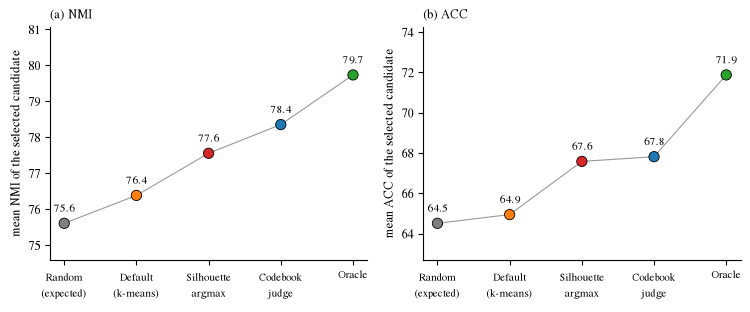

pools used: 95 (excluded 0 flat)
selects the gold-best candidate: judge 42% | silhouette 42% | random 12% by construction
oracle ceiling (mean best-candidate NMI): A pool 79.1 -> C pool 79.7 (+0.7)


In [5]:
# C EXHIBIT 4: selector comparison over the 8-candidate pools.
DC = pd.read_csv(RESULTS / 'selector_comparison_C_unmatched.csv')
v1 = DC.groupby(['bench', 'seed']).judge_scores_match.first().mean()
v2 = DC.groupby(['bench', 'seed']).winner_match.first().mean()
print(f'validation: judge scores reproduce on {v1:.0%} of pools, winner on {v2:.0%}')

recsC = {m: {'nmi': [], 'acc': []} for m in ('random', 'default', 'silhouette', 'judge', 'oracle')}
n_used = n_flat = t_sil = t_judge = 0
for (b, sd), g in DC.groupby(['bench', 'seed']):
    for metric in ('nmi', 'acc'):
        col = f'gold_{metric}'
        rand = g[col].mean(); orac = g[col].max()
        km2 = g.loc[g.candidate == 'kmeans_raw', col].iloc[0]
        sil = g.loc[g.silhouette.idxmax(), col]
        jdg = g.loc[g.candidate == g.regen_winner.iloc[0], col].iloc[0]
        if metric == 'nmi':
            if orac - rand < 0.5:
                n_flat += 1
                break
            n_used += 1
            t_sil += int(sil >= orac - 1e-9)
            t_judge += int(jdg >= orac - 1e-9)
        for m, v in (('random', rand), ('default', km2), ('silhouette', sil),
                     ('judge', jdg), ('oracle', orac)):
            recsC[m][metric].append(100 * (v - rand) / (orac - rand))

rawC = {m: {'nmi': [], 'acc': []} for m in SEL}
for (b, sd), g in DC.groupby(['bench', 'seed']):
    for met in ('nmi', 'acc'):
        c = f'gold_{met}'
        rawC['random'][met].append(g[c].mean())
        rawC['default'][met].append(g.loc[g.candidate == 'kmeans_raw', c].iloc[0])
        rawC['silhouette'][met].append(g.loc[g.silhouette.idxmax(), c])
        rawC['judge'][met].append(g.loc[g.candidate == g.regen_winner.iloc[0], c].iloc[0])
        rawC['oracle'][met].append(g[c].max())

with plt.rc_context(_RCA):
    fig, axs = plt.subplots(1, 2, figsize=(7.6, 3.2))
    for ax, metric, li in ((axs[0], 'nmi', 'a'), (axs[1], 'acc', 'b')):
        vals = [np.mean(rawC[m][metric]) for m in SEL]
        ax.scatter(np.arange(len(SEL)), vals, s=55, color=COLS, edgecolor='black',
                   lw=.6, zorder=3)
        for xi, v in enumerate(vals):
            ax.text(xi, v + (max(vals) - min(vals)) * 0.06, f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)
        ax.plot(np.arange(len(SEL)), vals, color='0.6', lw=.8, zorder=2)
        ax.set_xticks(np.arange(len(SEL)))
        ax.set_xticklabels(NAMES, fontsize=7.6)
        ax.set_title(f'({li}) {metric.upper()}', fontsize=9, loc='left')
        pad = (max(vals) - min(vals)) * 0.25
        ax.set_ylim(min(vals) - pad, max(vals) + pad * 1.3)
        ax.set_ylabel(f'mean {metric.upper()} of the selected candidate')
        for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
    plt.tight_layout()
    save(fig, 'rq3c_C_ex4_selector')
    plt.show()

print(f'pools used: {n_used} (excluded {n_flat} flat)')
print(f'selects the gold-best candidate: judge {100*t_judge/n_used:.0f}% | '
      f'silhouette {100*t_sil/n_used:.0f}% | random {100/8:.0f}% by construction')
oracA = np.mean(recs['oracle']['nmi']) if 'recs' in dir() else None
DA = pd.read_csv(RESULTS / 'selector_comparison_unmatched.csv')
oa = DA.groupby(['bench', 'seed']).gold_nmi.max().mean()
oc = DC.groupby(['bench', 'seed']).gold_nmi.max().mean()
print(f'oracle ceiling (mean best-candidate NMI): A pool {oa:.1f} -> C pool {oc:.1f} '
      f'({oc-oa:+.1f})')

## C Exhibit 5: repair ablation: selection-only vs full pipeline

The winning candidate's pre-repair gold score (from the selector-comparison
regeneration) against the run's final post-repair score. Repair is judge-gated,
so runs with rounds_kept = 0 must show a delta of exactly 0 (sanity check); for
kept rounds, the delta shows whether judge-approved repairs translate into
genuine gains against the human labels.

In [6]:
# C EXHIBIT 5: repair ablation (aligned unmatched): pre-repair winner vs final.
R = pd.read_csv(RESULTS / 'critclust_C_unmatched_aligned_runs.csv')       .drop_duplicates(['bench', 'seed'], keep='last')
pre = DC[DC.candidate == DC.regen_winner]         [['bench', 'seed', 'gold_nmi', 'gold_acc']]         .rename(columns={'gold_nmi': 'pre_nmi', 'gold_acc': 'pre_acc'})
M5 = R.merge(pre, on=['bench', 'seed'])
M5['d_nmi'] = (M5.nmi - M5.pre_nmi).round(2)
M5['d_acc'] = (M5.acc - M5.pre_acc).round(2)

zero = M5[M5.rounds_kept == 0]
print(f'sanity: {len(zero)} runs kept 0 rounds; max |delta| among them '
      f'{zero.d_nmi.abs().max():.2f} NMI (must be ~0)')

kept = M5[M5.rounds_kept > 0]
print(f'\nrepair touched {len(kept)}/{len(M5)} runs '
      f'({len(kept)/len(M5):.0%}); over those runs:')
print(f'  mean delta NMI {kept.d_nmi.mean():+.2f} | mean delta ACC {kept.d_acc.mean():+.2f}')
print(f'  gold improved on {(kept.d_nmi > 0).sum()}/{len(kept)} (NMI), '
      f'{(kept.d_acc > 0).sum()}/{len(kept)} (ACC); '
      f'hurt on {(kept.d_nmi < 0).sum()} / {(kept.d_acc < 0).sum()}')
print(f'\nover ALL {len(M5)} runs: mean delta NMI {M5.d_nmi.mean():+.2f}, '
      f'ACC {M5.d_acc.mean():+.2f}')

print('\ndelta by rounds kept:')
print(M5.groupby('rounds_kept')[['d_nmi', 'd_acc']].agg(['count', 'mean'])
        .round(2).to_string())

tab5 = M5.groupby('bench').agg(pre_nmi=('pre_nmi', 'mean'), post_nmi=('nmi', 'mean'),
                               d_nmi=('d_nmi', 'mean'), d_acc=('d_acc', 'mean'),
                               rounds=('rounds_kept', 'mean')).round(2)
tab5.index = [DISPL.get(b, b) for b in tab5.index]
print('\nper benchmark (means over seeds):')
print(tab5.sort_values('d_nmi', ascending=False).to_string())
tab5.to_csv(RESULTS / 'repair_ablation_C_unmatched.csv')
print('wrote results/repair_ablation_C_unmatched.csv')

sanity: 26 runs kept 0 rounds; max |delta| among them 0.00 NMI (must be ~0)

repair touched 69/95 runs (73%); over those runs:
  mean delta NMI +0.90 | mean delta ACC +1.08
  gold improved on 60/69 (NMI), 58/69 (ACC); hurt on 9 / 11

over ALL 95 runs: mean delta NMI +0.66, ACC +0.78

delta by rounds kept:
            d_nmi       d_acc      
            count  mean count  mean
rounds_kept                        
0              26  0.00    26  0.00
1              13  0.10    13  0.29
2              23  0.56    23  0.58
3              33  1.46    33  1.73

per benchmark (means over seeds):
               pre_nmi  post_nmi  d_nmi  d_acc  rounds
StackOverflow    84.63     87.66   3.03   3.32     3.0
DBPedia          82.94     84.81   1.87   0.51     2.0
StackEx-S2S      72.17     73.80   1.63   2.79     2.8
FewNerd          62.54     64.08   1.55   1.55     3.0
M-CID            78.79     80.18   1.39   1.60     1.6
Reddit-S2S       68.27     69.37   1.09   1.67     2.6
CLINC(D)         58.1